# Study of the implied constraints for MaxSAT only

In [1]:
!pwd

/Users/wilberquito/repos/mspsp/notebooks/smtapi/implied-impact/opb


In [2]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from typing import Optional
from pathlib import Path
from pprint import pprint

ROOT = Path().resolve().parent.parent.parent.parent
DATA = ROOT / "data"
FIGURES = ROOT / "figures"

pipe = "smtapi"
formalism = "opb"

DIRS = {
    "data": {
        "wandb": DATA / "wandb" / pipe,
        "analysis": DATA / "analysis" / pipe / formalism,
    },
    "figures": FIGURES / pipe / formalism,
}

pprint(DIRS)

{'data': {'analysis': PosixPath('/Users/wilberquito/repos/mspsp/data/analysis/smtapi/opb'),
          'wandb': PosixPath('/Users/wilberquito/repos/mspsp/data/wandb/smtapi')},
 'figures': PosixPath('/Users/wilberquito/repos/mspsp/figures/smtapi/opb')}


In [3]:
# This is used for sorting the configurations in the plots
CONFIG_ORDER = {
    "0000": 0,
    "1000": 1,
    "0100": 2,
    "0010": 3,
    "1100": 4,
    "0001": 5,
    "1001": 6,
    "0101": 7,
    "0011": 8,
}


# Stack the dataframes for all the configurations
def stack_frames(parent_dir: str, match: str | None = None) -> pd.DataFrame:
    frames = []
    for filename in os.listdir(parent_dir):
        if filename.endswith(".csv"):
            if match is not None:
                if match in filename:
                    csv_file = os.path.join(parent_dir, filename)
                    frames.append(pd.read_csv(csv_file))
                    print(f"Loaded {csv_file}")
                else:
                    print(f"Skipped {filename} (does not match '{match}')")
    return pd.concat(frames, ignore_index=True)

In [4]:
df = stack_frames(DIRS["data"]["wandb"], match=formalism)

Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=evalmaxsat__i=i1=0,i2=1,i3=0,i4=0.csv (does not match 'opb')
Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=evalmaxsat__i=i1=1,i2=0,i3=0,i4=0.csv (does not match 'opb')
Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=1.csv (does not match 'opb')
Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=1,i4=0.csv (does not match 'opb')
Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=0,i3=0,i4=0.csv (does not match 'opb')
Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=1,i2=1,i3=0,i4=0.csv (does not match 'opb')
Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=1,i2=0,i3=0,i4=0.csv (does not match 'opb')
Skipped smtapi-MSPSP__ma_grups@f=maxsat__s=maxcdcl__i=i1=0,i2=1,i3=0,i4=0.csv (does not match 'opb')
Loaded /Users/wilberquito/repos/mspsp/data/wandb/smtapi/smtapi-MSPSP__ma_grups@f=opb__s=exactpb__i=i1=0,i2=0,i3=1,i4=0__pb_like=0.csv
Loaded /Users/wilberquito/repos/mspsp/data/wandb/smt

In [5]:
# Adds the column group from the `mspsp_instance`
def add_group_column(df: pd.DataFrame) -> pd.DataFrame:
    df["group"] = df["mspsp_instance"].apply(lambda x: x.split("/")[-2])
    return df


# Adds the implied configuration column
def add_implied_column(df: pd.DataFrame, check: bool) -> pd.DataFrame:
    # Creamos un ID único para la configuración de implied constraints

    impl_cols = [c for c in df.columns if "implied_" in c]
    df["implied"] = df[impl_cols].apply(
        lambda x: "".join(["1" if val else "0" for val in x]), axis=1
    )

    if check:
        config_count = df["implied"].value_counts()
        s = config_count.iloc[0]
        diff_n_count = 0
        logger: list[str] = list()

        for i, c in enumerate(config_count):
            if c != s:
                diff_n_count += 1
                logger.append(config_count.index[i])

        if diff_n_count > 0:
            print(
                f"WARNING: Configuration count mismatch: {diff_n_count} configurations have a different count than the first one"
            )
            print("Mismatched configurations:", logger)

    return df


# Adds column to know if the optimum was found
def add_accomplished_column(df: pd.DataFrame) -> pd.DataFrame:
    df["accomplished"] = df.apply(
        lambda row: row["solution_status"].lower() == "optimum_found", axis=1
    )
    return df


# Excludes the specified groups from the dataframe
def exclude_groups(df: pd.DataFrame, groups: list[str]) -> pd.DataFrame:
    return df[~df["group"].isin(groups)].copy()


df = add_group_column(df)
df = add_implied_column(df, check=True)
df = add_accomplished_column(df)
df = exclude_groups(df, groups=[])

In [6]:
df.head(2)

,Unnamed: 0,name,formalism,implied_1,implied_2,implied_3,implied_4,inline_config,mspsp_instance,pb_like,...,makespan,model,slurm.timeout,solution_status,solver.real_time,solver.sys_time,solver.user_time,group,implied,accomplished
0,0,prime-blood-wine-1,opb,0.0,0.0,1.0,0.0,"f=opb__s=exactpb__i=i1=0,i2=0,i3=1,i4=0__pb_li...",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,0.0,...,61.0,v S_0:0; S_1:18; S_2:1; S_3:0; S_4:9; S_5:12; ...,False,OPTIMUM_FOUND,0.33,0.01,0.27,set-1a,0010,True
1,1,futile-farpoint-2,opb,0.0,0.0,1.0,0.0,"f=opb__s=exactpb__i=i1=0,i2=0,i3=1,i4=0__pb_li...",./modules/rcpsp-instances/MSPSP/set-1a/inst_se...,0.0,...,66.0,v S_0:0; S_1:10; S_2:6; S_3:0; S_4:13; S_5:33;...,False,OPTIMUM_FOUND,0.22,0.00,0.20,set-1a,0010,True


In [7]:
df.columns

Index(['Unnamed: 0', 'name', 'formalism', 'implied_1', 'implied_2',
       'implied_3', 'implied_4', 'inline_config', 'mspsp_instance', 'pb_like',
       'solver', 'solving_timeout_s', 'encoder.real_time', 'encoder.sys_time',
       'encoder.user_time', 'makespan', 'model', 'slurm.timeout',
       'solution_status', 'solver.real_time', 'solver.sys_time',
       'solver.user_time', 'group', 'implied', 'accomplished'],
      dtype='object')

In [8]:
df.shape

(13704, 25)

In [9]:
projects = df["inline_config"].unique()
len(projects), projects

(12,
 array(['f=opb__s=exactpb__i=i1=0,i2=0,i3=1,i4=0__pb_like=0',
        'f=opb__s=roundingsat__i=i1=1,i2=1,i3=0,i4=0__pb_like=0',
        'f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=0__pb_like=0',
        'f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=1__pb_like=0',
        'f=opb__s=exactpb__i=i1=0,i2=0,i3=0,i4=1__pb_like=0',
        'f=opb__s=roundingsat__i=i1=0,i2=0,i3=0,i4=0__pb_like=0',
        'f=opb__s=exactpb__i=i1=1,i2=1,i3=0,i4=0__pb_like=0',
        'f=opb__s=roundingsat__i=i1=0,i2=0,i3=1,i4=0__pb_like=0',
        'f=opb__s=exactpb__i=i1=1,i2=0,i3=0,i4=0__pb_like=0',
        'f=opb__s=roundingsat__i=i1=0,i2=1,i3=0,i4=0__pb_like=0',
        'f=opb__s=exactpb__i=i1=0,i2=1,i3=0,i4=0__pb_like=0',
        'f=opb__s=roundingsat__i=i1=1,i2=0,i3=0,i4=0__pb_like=0'],
       dtype=object))

In [10]:
def visualize_implied_impact_per_family_success_rate(
    _df: pd.DataFrame,
    save_as: Optional[str] = None,
    title: str = "Impact of Implied Constraints per Family (% Solved)",
):
    """Visualiza la tasa de éxito de las soluciones por configuración de restricciones implícitas."""
    df = _df.copy()

    pivot_success = df.pivot_table(
        index="group",
        columns="implied",
        values="accomplished",
        aggfunc="mean",
    )

    pivot_count = df.pivot_table(
        index="group",
        columns="implied",
        values="accomplished",
        aggfunc="count",
    )

    pivot_success = pivot_success.loc[
        :, [k for k in CONFIG_ORDER.keys() if k in pivot_count.keys()]
    ]
    pivot_count = pivot_count.loc[
        :, [k for k in CONFIG_ORDER.keys() if k in pivot_count.keys()]
    ]

    annot_labels = pivot_success.copy().astype(str)
    for i in range(pivot_success.shape[0]):
        for j in range(pivot_success.shape[1]):
            val = pivot_success.iloc[i, j]
            count = pivot_count.iloc[i, j]
            # Use \n for a line break inside the cell
            annot_labels.iloc[i, j] = f"{val:.2%}\n({int(count)})"

    plt.figure(figsize=(10, 6))

    sns.heatmap(
        pivot_success,
        annot=annot_labels,
        cmap="YlGnBu",
        fmt="",
        cbar_kws={"label": "Success Rate"},
    )

    plt.xlabel("Implied Bitmasks")
    plt.ylabel("Instance Families")

    plt.title(title)
    plt.tight_layout()

    if save_as:
        plt.savefig(save_as)
    else:
        plt.savefig("./heatmap_exito.png")

In [11]:
def analyze_impact_per_family(
    df: pd.DataFrame,
    title: str = "Impact of Implied Constraints per Family (% Solved) - Only PB",
    save_as: Optional[str] = None,
) -> pd.DataFrame:

    visualize_implied_impact_per_family_success_rate(
        df,
        save_as=save_as,
        title=title,
    )

    summary = (
        df.groupby(["group", "implied"])
        .agg(
            total=("accomplished", "count"),
            timeout=("accomplished", lambda x: np.sum(x == False)),
            timeout_pct=("accomplished", lambda x: np.mean(x == False) * 100),
            solved=("accomplished", "sum"),
            solved_pct=("accomplished", lambda x: np.mean(x) * 100),
            q1=("solver.real_time", lambda x: np.percentile(x, 25)),
            med=("solver.real_time", "median"),
            q3=("solver.real_time", lambda x: np.percentile(x, 75)),
            avg=("solver.real_time", "mean"),
        )
        .reset_index()
    )

    # Get baseline (implied == "0000") per group
    base = summary[summary["implied"] == "0000"][["group", "solved_pct", "solved"]]
    base = base.rename(
        columns={
            "solved_pct": "base_solved_pct",
            "solved": "base_solved",
        }
    )

    summary = summary.merge(base, on="group")

    summary["solved_progress"] = summary["solved"] - summary["base_solved"]
    summary["solved_progress_pct"] = summary["solved_pct"] - summary["base_solved_pct"]

    for col in [
        "q1",
        "med",
        "q3",
        "avg",
        "solved",
        "solved_progress",
        "solved_progress_pct",
        "solved_pct",
        "timeout",
        "timeout_pct",
    ]:
        summary[col] = summary[col].round(2)

    # Sort the columns order
    col_order = [
        "group",
        "implied",
        "total",
        "timeout",
        "timeout_pct",
        "solved",
        "solved_pct",
        "solved_progress",
        "solved_progress_pct",
        "q1",
        "med",
        "q3",
        "avg",
    ]

    summary = summary[col_order]

    # Sort by group and implied configuration order
    summary["config_order"] = summary["implied"].map(lambda x: CONFIG_ORDER.get(x, 999))
    summary = summary.sort_values(by=["group", "config_order"])

    # Drop the config_order column as it's no longer needed
    summary = summary.drop(columns=["config_order"])

    # Rename columns

    summary.rename(
        columns={
            "group": "family",
            "implied": "implied",
            "total": "n.",
            "timeout": "t.o",
            "timeout_pct": "t.o %",
            "solved": "n. solved",
            "solved_pct": "solved %",
            "solved_progress_pct": "progress vs base (%)",
            "solved_progress": "progress vs base",
            "q1": "q1.",
            "med": "med.",
            "q3": "q3.",
            "avg": "avg.",
        },
        inplace=True,
    )

    summary.reset_index(drop=True, inplace=True)
    return summary

,family,implied,n.,t.o,t.o %,n. solved,solved %,progress vs base,progress vs base (%),q1.,med.,q3.,avg.
0,set-1a,0000,432,81,18.75,351,81.25,0,0.00,0.25,1.83,124.52,136.14
1,set-1a,1000,432,77,17.82,355,82.18,4,0.93,0.24,1.14,79.69,126.71
2,set-1a,0100,432,2,0.46,430,99.54,79,18.29,0.20,0.36,1.88,12.68
3,set-1a,0010,432,4,0.93,428,99.07,77,17.82,0.19,0.31,0.57,13.13
4,set-1a,1100,432,2,0.46,430,99.54,79,18.29,0.20,0.34,0.88,12.42
5,set-1a,0001,432,11,2.55,421,97.45,70,16.20,0.28,0.54,7.85,34.00
6,set-1b,0000,432,417,96.53,15,3.47,0,0.00,600.00,600.00,600.00,583.01
7,set-1b,1000,432,416,96.30,16,3.70,1,0.23,600.00,600.00,600.00,581.08
8,set-1b,0100,432,376,87.04,56,12.96,41,9.49,600.00,600.00,600.00,537.92
9,set-1b,0010,432,328,75.93,104,24.07,89,20.60,600.00,600.00,600.00,487.17


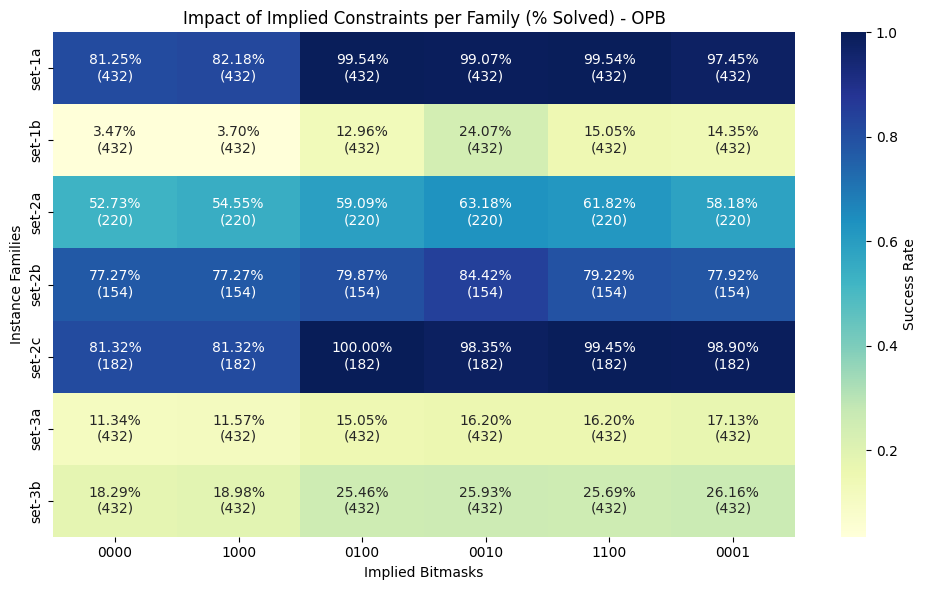

In [12]:
summary = analyze_impact_per_family(
    df,
    title=f"Impact of Implied Constraints per Family (% Solved) - {formalism.upper()}",
    save_as=os.path.join(DIRS["figures"], "implied_impact_per_family_heatmap.png"),
)
summary.to_csv(os.path.join(DIRS["data"]["analysis"], "implied_impact_per_family.csv"))
summary

### Individual solver analysis

Summary for solver exactpb:
    family implied   n.  t.o  t.o %  n. solved  solved %  progress vs base  progress vs base (%)     q1.    med.     q3.    avg.
0   set-1a    0000  216   37  17.13        179     82.87                 0                  0.00    0.20    1.18   69.65  125.01
1   set-1a    1000  216   36  16.67        180     83.33                 1                  0.46    0.19    0.66   60.01  119.09
2   set-1a    0100  216    2   0.93        214     99.07                35                 16.20    0.17    0.24    1.47   13.03
3   set-1a    0010  216    2   0.93        214     99.07                35                 16.20    0.16    0.21    0.40   12.59
4   set-1a    1100  216    2   0.93        214     99.07                35                 16.20    0.16    0.24    0.63   12.64
5   set-1a    0001  216    3   1.39        213     98.61                34                 15.74    0.18    0.30    3.26   20.41
6   set-1b    0000  216  204  94.44         12      5.56             

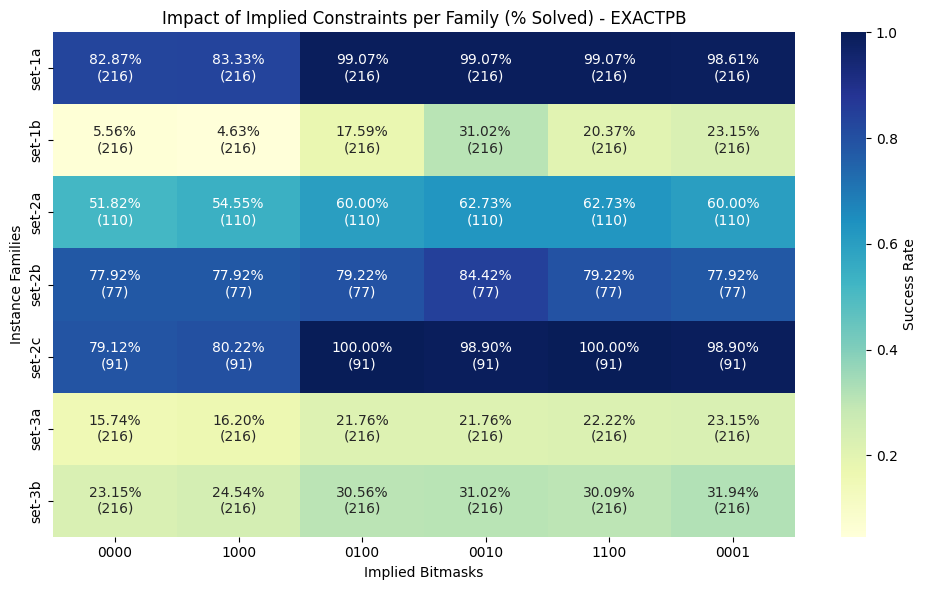

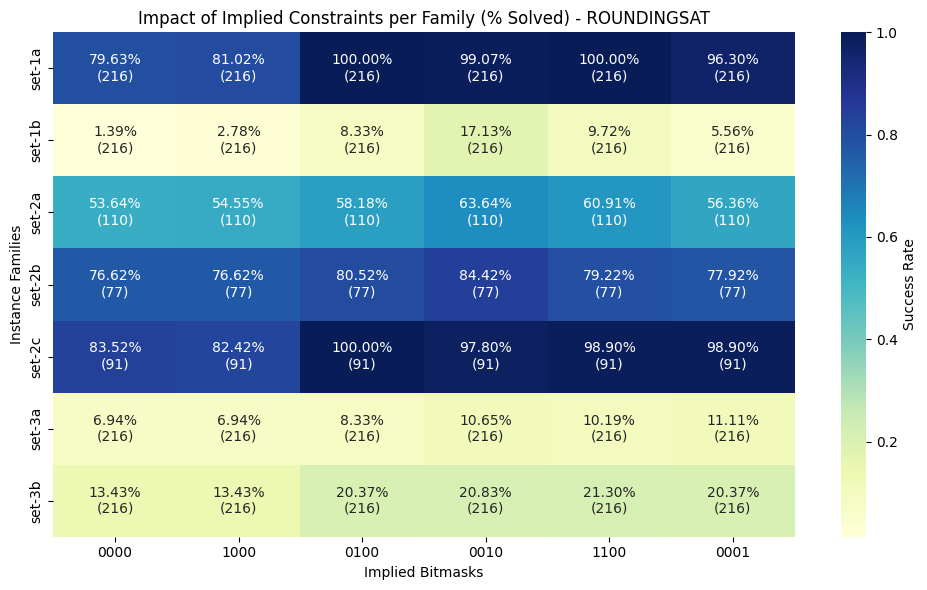

In [13]:
solvers = df["solver"].unique()

for s in solvers:
    solver_df = df[df["solver"] == s]

    summary = analyze_impact_per_family(
        solver_df,
        title=f"Impact of Implied Constraints per Family (% Solved) - {s.upper()}",
        save_as=os.path.join(
            DIRS["figures"], f"{s}_implied_impact_per_family_heatmap.png"
        ),
    )
    summary.to_csv(
        os.path.join(DIRS["data"]["analysis"], f"{s}_implied_impact_per_family.csv")
    )
    print(f"Summary for solver {s}:\n{summary.to_string()}\n")